In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

In [4]:
import numpy as np
import yfinance as yf

sp500_tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B",
    "JPM", "JNJ", "V", "UNH", "XOM", "PG", "MA", "HD", "CVX", "MRK",
    "ABBV", "PEP", "KO", "AVGO", "COST", "MCD", "WMT", "BAC", "CRM",
    "ACN", "LLY", "TMO", "CSCO", "ABT", "NKE", "NEE", "DHR", "TXN",
    "ORCL", "PM", "MS", "RTX", "AMGN", "HON", "UPS", "QCOM", "IBM",
    "GS", "CAT", "SBUX", "BA", "GE"
]

crypto_tickers = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]
all_tickers = sp500_tickers + crypto_tickers

raw = yf.download(all_tickers, start="2019-01-01", end="2024-12-31", auto_adjust=True)
prices = raw.xs("Close", axis=1, level="Price")
prices = prices.dropna(how="all")
prices = prices.dropna(axis=1, thresh=int(0.5 * len(prices)))

returns = np.log(prices / prices.shift(1)).dropna(how="all")
corr_matrix = returns.corr()

print(f"Assets: {corr_matrix.shape[0]}, Returns shape: {returns.shape}")

[*********************100%***********************]  55 of 55 completed


Assets: 55, Returns shape: (2190, 55)


Building the network. Here we are not building a connection between all of the nodes, but only nodes (stocks) that correlate >0.5 (we call this filtered correlation network).

In [6]:
#Correlation threshold - only keep strong relationships
threshold = 0.5

#Create an empty undirected graph
G = nx.Graph()

#Add all assets as nodes
G.add_nodes_from(corr_matrix.columns)

#Add edges where correlation exceeds the threshold
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        asset_i = corr_matrix.columns[i]
        asset_j = corr_matrix.columns[j]
        correlation = corr_matrix.loc[asset_i, asset_j]
        if correlation > threshold:
            G.add_edge(asset_i, asset_j, weight=correlation)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")


Nodes: 55
Edges: 242


242 edges, means out of the possible 1485 pairs (54*55/2), only 16% of the connections are strong enough to make the cut.
Notice that a fully connected network would be noise (we are searching for signal).

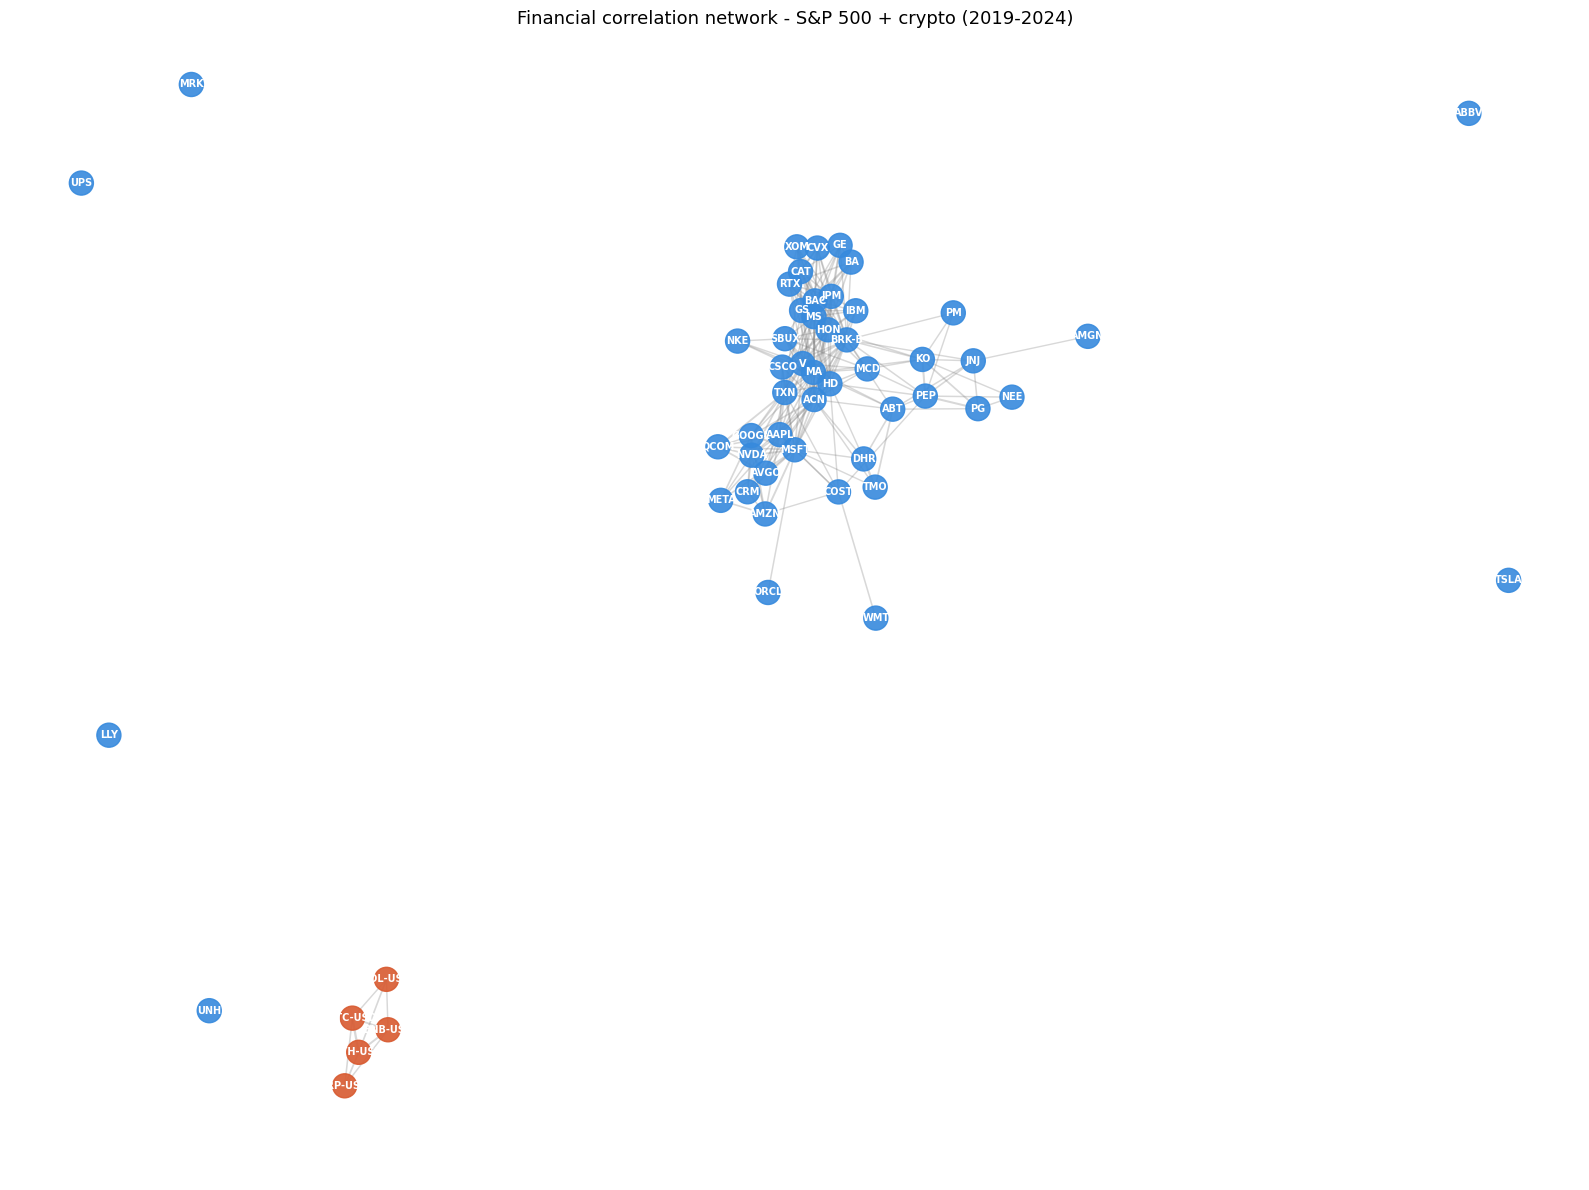

In [10]:
#Separate crypto and stock nodes for coloring
crypto = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]
node_colors = ["#D85A30" if node in crypto else "#378ADD" for node in G.nodes()]

#Edge weights for line thickness
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
edge_widths = [w * 2 for w in edge_weights]

#Layout - spring layout spaces nodes by connection strengh
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, weight="weight", seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color="gray")

plt.title("Financial correlation network - S&P 500 + crypto (2019-2024)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("network_graph.png", dpi=150)
plt.show()

The spring layout reveals two completely separate clusters:
- A dense equity cluster containing ~45 S&P 500 stocks with strong cross-correlations
- An isolated crypto cluster with internal correlation but zero connection to equities
- Several peripheral stocks (TSLA, LLY, MRK, UPS) that act as natural diversifiers

This structure has direct portfolio implications — crypto and peripheral stocks provide genuine diversification from the core equity risk factor.

In [11]:
isolated = [node for node in G.nodes() if G.degree(node) == 0]
print("Isolated nodes:", isolated)

Isolated nodes: ['ABBV', 'LLY', 'MRK', 'TSLA', 'UNH', 'UPS']
